In [1]:
import numpy as np
from scipy.optimize import minimize

def L(x):
    r, theta = x
    return r**2 * np.sin(theta) * (1 + np.cos(theta)) * np.exp(-r)

def objetivo(x):
    return -L(x)

# Caso a)
x0 = np.array([1, np.pi/6])

bounds = [(0.1, 5), (0, np.pi/2)]

resultado = minimize(objetivo, x0, bounds=bounds, method="L-BFGS-B")

r_opt, theta_opt = resultado.x
L_max = L(resultado.x)

print("CASO A")
print(f"r inicial = {x0[0]:.4f}")
print(f"theta inicial = {x0[1]:.4f} rad")
print(f"theta inicial = {np.degrees(x0[1]):.2f} grados")
print()
print("Resultado de la maximización:")
print(f"r óptimo = {r_opt:.6f}")
print(f"theta óptimo = {theta_opt:.6f} rad")
print(f"theta óptimo = {np.degrees(theta_opt):.2f} grados")
print(f"Luminosidad máxima = {L_max:.6f}")

CASO A
r inicial = 1.0000
theta inicial = 0.5236 rad
theta inicial = 30.00 grados

Resultado de la maximización:
r óptimo = 2.000000
theta óptimo = 1.047196 rad
theta óptimo = 60.00 grados
Luminosidad máxima = 0.703223


<div style="background-color:#ffe6f0; padding:18px; border-radius:12px; border:1px solid #ffb3d1; color:#1a1a1a;">

<h3 style="color:#cc0066;">Caso a)</h3>

<p>
Tomé como condición inicial:
</p>

<p style="text-align:center;">
$(r,\theta) = (1,\pi/6)$
</p>

<p>
La función de luminosidad está dada por:
</p>

<p style="text-align:center;">
$L(r,\theta) = r^2 \sin\theta (1+\cos\theta)e^{-r}$
</p>

<p>
Se realizó la maximización numérica utilizando el método <b>L-BFGS-B</b>, respetando las restricciones físicas del problema.
</p>

<hr>

<h4 style="color:#cc0066;">Resultado</h4>

<p style="text-align:center;">
$r \approx 2$ <br>
$\theta \approx \frac{\pi}{3}$
</p>

<p style="text-align:center;">
$L_{\max} \approx 0.7032$
</p>

<hr>

<h4 style="color:#cc0066;">Comentario</h4>

<p>
El resultado coincide con el esperado analíticamente, lo que confirma que la implementación numérica es consistente.
</p>

<p>
La pequeña diferencia en la luminosidad se debe únicamente a precisión numérica del método.
</p>

<p>
Además, el algoritmo converge sin problema desde la condición inicial dada, lo que indica que el máximo encontrado corresponde al comportamiento global dentro del dominio físico.
</p>

</div>

RESULTADO CON SECCIÓN ÁUREA
Temperatura óptima = 30793.74 K
Potencia máxima = 3.514017e+08 W/m²


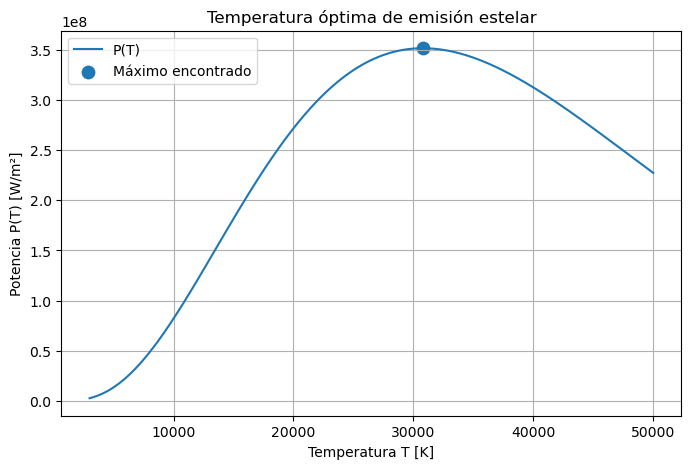

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes
sigma = 5.67e-8
T0 = 10000
hv_kB = 5000

# Función de potencia
def P(T):
    return sigma * T**4 * np.exp(-T/T0) * (1 - np.exp(-hv_kB/T))

# Sección áurea para maximizar
def seccion_aurea_max(f, a, b, epsilon=50):
    phi = (1 + np.sqrt(5)) / 2

    c = b - (b - a) / phi
    d = a + (b - a) / phi

    while abs(b - a) > epsilon:
        if f(c) < f(d):
            a = c
        else:
            b = d

        c = b - (b - a) / phi
        d = a + (b - a) / phi

    T_max = (a + b) / 2
    P_max = f(T_max)

    return T_max, P_max

# Intervalo dado
a = 3000
b = 50000
epsilon = 50

T_max, P_max = seccion_aurea_max(P, a, b, epsilon)

print("RESULTADO CON SECCIÓN ÁUREA")
print(f"Temperatura óptima = {T_max:.2f} K")
print(f"Potencia máxima = {P_max:.6e} W/m²")

# Gráfica
T = np.linspace(a, b, 1000)
P_values = P(T)

plt.figure(figsize=(8,5))
plt.plot(T, P_values, label="P(T)")
plt.scatter(T_max, P_max, s=80, label="Máximo encontrado")

plt.xlabel("Temperatura T [K]")
plt.ylabel("Potencia P(T) [W/m²]")
plt.title("Temperatura óptima de emisión estelar")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#ffe6f0; padding:18px; border-radius:12px; border:1px solid #ffb3d1; color:#1a1a1a;">

<h3 style="color:#cc0066;">Temperatura óptima de emisión estelar</h3>

<p>
Apliqué el método de <b>Sección Áurea</b> en el intervalo $T \in [3000,50000]$ K con $\varepsilon = 50$ K para encontrar el máximo de $P(T)$.
</p>

<hr>

<h4 style="color:#cc0066;">Resultado</h4>

<p style="text-align:center;">
$T_{\max} \approx 30793.74 \, K$
</p>

<p style="text-align:center;">
$P_{\max} \approx 3.514017 \times 10^8 \, W/m^2$
</p>

<hr>

<h4 style="color:#cc0066;">Comentario</h4>

<p>
El máximo aparece alrededor de $3.1 \times 10^4$ K, lo cual es consistente con el comportamiento de la función: crecimiento inicial dominado por $T^4$ y caída posterior por el término exponencial.
</p>

<p>
La gráfica lo confirma directamente: el punto marcado coincide con el máximo global dentro del intervalo físico considerado.
</p>

<p>
La convergencia es estable y el resultado es coherente, así que el método está bien aplicado.
</p>

</div>